<a href="https://colab.research.google.com/github/mandalbitayan/Accident_area_map/blob/main/Accident_Road_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import branca.colormap as cm

In [ ]:
gdf = gpd.read_file("/content/Road_accident.geojson")

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 90598 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 86709 entries, 0 to 86708
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   fid          86709 non-null  int32   
 1   osm_id       86709 non-null  object  
 2   code         86709 non-null  int32   
 3   fclass       86709 non-null  object  
 4   layer        86709 non-null  int32   
 5   id           86709 non-null  int32   
 6   _Medianmean  86709 non-null  float64 
 7   geometry     86709 non-null  geometry
dtypes: float64(1), geometry(1), int32(4), object(2)
memory usage: 4.0+ MB


In [ ]:
gdf.head()

,fid,osm_id,code,fclass,layer,id,_Medianmean,geometry
0,1,4059955,5114,secondary,0,58303,1.259259,"LINESTRING (19.04973 47.48765, 19.04983 47.487..."
1,2,4059964,5115,tertiary,0,59919,47.910000,"LINESTRING (19.05567 47.52694, 19.05518 47.526..."
2,3,4059966,5124,pedestrian,0,59980,1.566667,"LINESTRING (19.05797 47.48741, 19.05755 47.487..."
3,4,4380556,5115,tertiary,0,75575,70.233333,"LINESTRING (19.08905 47.47907, 19.08877 47.478..."
4,5,4380561,5122,residential,0,77217,35.024691,"LINESTRING (19.09196 47.50386, 19.09198 47.505..."


In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

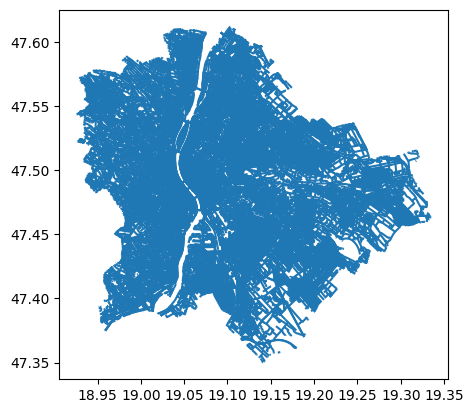

In [ ]:
gdf.plot()

In [ ]:
colorMap = cm.LinearColormap(
    colors = list(reversed(cm.linear.RdYlGn_11.colors)),
    vmin = gdf["_Medianmean"].min(),
    vmax = gdf["_Medianmean"].max()
)
colorMap

In [ ]:
minx,miny,maxx,maxy = gdf.total_bounds
center = [(miny+maxy)/2,(minx+maxx)/2]

In [ ]:
m = folium.Map(location=center,zoom_start=11,tiles="CartoDB positron")
folium.GeoJson(
    gdf,
    style_function = lambda feature:{
        "color":colorMap(feature["properties"]["_Medianmean"]),
        "weight":2,
        "opacity":0.5
    }

).add_to(m)

colorMap.caption="Traffic accident (2015-2018)"
colorMap.add_to(m)

m.fit_bounds([[miny,minx],[maxy,maxx]])


In [ ]:
m